In [14]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadraticEquationInput(TypedDict):
    a: int
    b: int
    c: int

    equation:str
    discriminator:float
    result:str

In [4]:
def check_discriminator(state: QuadraticEquationInput):
    discriminator = (state['b']**2)-4*(state['a']*state['c'])

    return {'discriminator': discriminator}

In [35]:
def make_equation(state: QuadraticEquationInput):
    equation = f"{state['a']}X2 {state['b']:+}X {state['c']:+}"
    return {'equation': equation}

In [51]:
def real_roots(state: QuadraticEquationInput):
    root1 = (-state['b'] + (state['discriminator']**0.5)) / (2*state['a'])
    root2 = (-state['b'] - (state['discriminator']**0.5))/ (2*state['a'])

    root = f'real roots are : {root1}  and  {root2}'
    return {'result': root}

In [16]:
def repeated_roots(state: QuadraticEquationInput):
    root1 = -state['b'] / (2*state['a'])

    root = f'repeated roots are : {root1}'
    return {'result': root}

In [17]:
def no_roots(state: QuadraticEquationInput):

    root = f'No roots ...'
    return {'result': root}

In [18]:
def check_condition(state: QuadraticEquationInput) -> Literal['real_roots', 'repeated_roots' , 'no_roots'] :
    if state['discriminator']>0:
        return 'real_roots'
    elif state['discriminator']==0:
        return 'repeated_roots'
    else:
        return 'no_roots'

In [52]:
graph = StateGraph(QuadraticEquationInput)

graph.add_node('check_discriminator', check_discriminator)
graph.add_node('make_equation', make_equation)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_roots', no_roots)

graph.add_edge(START, 'make_equation')
graph.add_edge('make_equation', 'check_discriminator')

graph.add_conditional_edges('check_discriminator', check_condition)

graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_roots', END)

workflow=graph.compile()

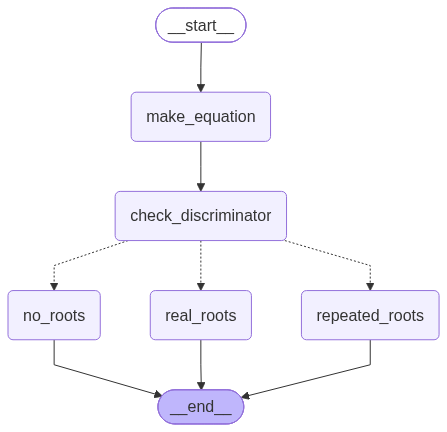

In [32]:
workflow

In [59]:
initial_state = {'a':1, 'b':8, 'c':0}
final_state = workflow.invoke(initial_state)

In [60]:
print(final_state)

{'a': 1, 'b': 8, 'c': 0, 'equation': '1X2 +8X +0', 'discriminator': 64, 'result': 'real roots are : 0.0  and  -8.0'}
